In [1]:
import pyBigWig

from efficient_apriori import apriori

import matplotlib
#matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import Shadow
from matplotlib import patches

import pickle
import json
import numpy as np
import random

In [2]:
def get_gene_dict(data):
    symbol_standard_values = {}
    associations = data.get('associations', [])
    for association in associations:
        gene_symbol = association.get('gene', {}).get('symbol')
        standardized_value = association.get('standardizedValue')
        if gene_symbol is not None and standardized_value is not None:
            symbol_standard_values[gene_symbol] = standardized_value
            
    return symbol_standard_values


def map_gene_values(gene_names, gene_dict):
    genes = gene_names.split(',') # 按逗号+空格分割基因名字符串
    mapped_values = []
    for gene in genes:
        if gene in gene_dict.keys():
            mapped_values.append(gene_dict[gene])
    return mapped_values

In [3]:
import pandas as pd
from matplotlib.axes import Axes

from trackc.pl.bigwig import _make_multi_region_ax
from trackc.tl._getRegionsCmat import GenomeRegion


def gene_track(
    ax = None,
    bed12 = None,
    regions = None,
    track_type = "gene",
    show_label = True,
    pos_strand_gene_color = "#3366CC",
    neg_strand_gene_color = "#EECFA1",
    line = 1,
    gene_fontszie = 7,
    label = None,
    label_rotation = 0,
    label_fontsize = 16,
    ax_on = False,
):

    if isinstance(regions, list):
        line_GenomeRegions = pd.concat(
            [GenomeRegion(i).GenomeRegion2df() for i in regions]
        )
    else:
        line_GenomeRegions = GenomeRegion(regions).GenomeRegion2df()

    axs = _make_multi_region_ax(ax, line_GenomeRegions)
    line_GenomeRegions = line_GenomeRegions.reset_index()

    ax.set_ylabel(
        label,
        fontsize=label_fontsize,
        rotation=label_rotation,
        horizontalalignment="right",
        verticalalignment="center",
    )

    ax.set_xticks([])
    ax.set_xticklabels("")
    ax.set_yticks([])
    ax.set_yticklabels("")
    if ax_on == False:
        spines = ["top", "bottom", "left", "right"]
        for i in spines:
            ax.spines[i].set_color("none")

    if isinstance(bed12, str):
        bed12 = pd.read_table(bed12, sep="\t", header=None)

    bed12 = bed12.iloc[:, 0:12]
    bed12.columns = [
        "chrom",
        "start",
        "end",
        "name",
        "score",
        "strand",
        "thickStart",
        "thickEnd",
        "itemRgb",
        "blockCount",
        "blockSizes",
        "blockStarts",
    ]
    bed12["blockSizes"] = bed12["blockSizes"].str.rstrip(",")
    bed12["blockStarts"] = bed12["blockStarts"].str.rstrip(",")
    bed12["chrom"] = bed12["chrom"].astype(str)
    chrom_names = bed12["chrom"].unique()

    for ix, row in line_GenomeRegions.iterrows():
        if row["chrom"] not in chrom_names:
            raw_chr = row["chrom"]
            if row["chrom"].startswith("chr"):
                row["chrom"] = row["chrom"].lstrip("chr")
            else:
                row["chrom"] = "chr" + row["chrom"]
            if row["chrom"] not in chrom_names:
                print(f"{raw_chr} not in bigwig chroms!")
                return

        if track_type == "gene":
            _plot_gene(
                axs[ix],
                bed12,
                row["chrom"],
                row["fetch_start"],
                row["fetch_end"],
                needReverse=row["isReverse"],
                show_label=show_label,
                pos_strand_gene_color=pos_strand_gene_color,
                neg_strand_gene_color=neg_strand_gene_color,
                line=line,
                fontszie=gene_fontszie,
                ax_on=ax_on,
            )
        if track_type == "density":
            print("This gene type is developping")
        else:
            pass


def _plot_gene(
    ax,
    gene_bed,
    chrom,
    start,
    end,
    needReverse=False,
    show_label=True,
    pos_strand_gene_color="#3366CC",
    neg_strand_gene_color="#EECFA1",
    line=1,
    fontszie=5,
    ax_on=False,
):
    gene_bed = gene_bed[gene_bed["chrom"] == chrom]
    gene_bed_plot = gene_bed[
        ((gene_bed["start"] >= start) & (gene_bed["start"] <= end))
        | ((gene_bed["end"] >= start) & (gene_bed["end"] <= end))
    ]
    gene_bed_plot = gene_bed_plot.sort_values(by="end")
    # print(gene_bed_plot

    plot_gene_num = gene_bed_plot.shape[0]

    ii = 0
    head_length = (abs(end - start) / (line + 2)) / 5
    if line <= 3:
        head_length = (abs(end - start) / (line * 3)) / 10

    for i, row in gene_bed_plot.iterrows():
        # col = pos_strand_gene_color
        text_col = pos_strand_gene_color

        if row["strand"] == "-":
            # col = neg_strand_gene_color
            text_col = neg_strand_gene_color

        # text_col = col
        
        if row["strand"] == "+":
            plot_y = 0
            
        elif row["strand"] == "-":
            plot_y = 1
        
        #plot_y = ii % line

        ax.plot(
            (row["start"], row["end"]),
            (plot_y + 0.5, plot_y + 0.5),
            color="k",
            linewidth=1,
            solid_capstyle="butt",
        )
        starts = [int(x) for x in row["blockStarts"].split(",")]
        widths = [int(x) for x in row["blockSizes"].split(",")]

        ax.bar(
            x=starts,
            height=0.4,
            width=widths,
            bottom=plot_y + 0.3,
            edgecolor="k",
            linewidth=1,
            align="edge",
            color="k",
        )

        if row["start"] < start:
            row["start"] = start
        if row["end"] > end:
            row["end"] = end

        arrow_s = row["end"]
        dx = 0.3
        if row["strand"] == "-":
            arrow_s = row["start"]
            dx = -0.1
        ax.arrow(
            arrow_s,
            plot_y + 0.5,
            dx,
            0,
            overhang=0.5,
            width=0,
            head_width=0.28,
            head_length=head_length,
            length_includes_head=False,
            color=text_col,
            linewidth=0.5,
        )
        if isinstance(show_label, bool):
            if show_label == False:
                ii += 1
                continue
        if isinstance(show_label, str):
            if row["name"] != show_label:
                ii += 1
                continue
        if isinstance(show_label, list):
            if row["name"] not in show_label:
                ii += 1
                continue

        if (row["name"] in gene_bed_plot.iloc[-4:, :]["name"]) or (
            int(line / (ii + 1)) < 2
        ):
            ha = "center"
            genename = row["name"] + "  "
            xpos = (row["start"]+row["end"])/2
            if needReverse:
                ha = "center"
                genename = "  " + row["name"]
                # xpos = row['end']
            ypos = plot_y #+ 0.5
            if line == 1:
                xpos = row["start"] + abs(row["start"] - row["end"]) / 2
                ypos = 0.8
                ha = "center"
                
            if row["strand"] == "+":
                ax.text(
                xpos,
                ypos-0.2,
                genename + "  ",
                ha=ha,
                va="top",#"center",
                color=text_col,
                fontsize=fontszie,)

            elif row["strand"] == "-":
                ax.text(
                xpos,
                ypos+1.2,
                genename + "  ",
                ha=ha,
                va="bottom",#"center",
                color=text_col,
                fontsize=fontszie,)


        else:
            ha = "center"
            genename = "  " + row["name"]
            xpos = (row["start"]+row["end"])/2
            if needReverse:
                ha = "center"
                genename = row["name"] + "  "
                # xpos = row['start']

            ypos = plot_y #+ 0.5
            if line == 1:
                xpos = row["start"] + abs(row["start"] - row["end"]) / 2
                ypos = 0.8
                ha = "center"
                
            if row["strand"] == "+":
                ax.text(
                xpos,
                ypos-0.2,
                genename + "  ",
                ha=ha,
                va="top",#"center",
                color=text_col,
                fontsize=fontszie,)

            elif row["strand"] == "-":
                ax.text(
                xpos,
                ypos+1.2,
                genename + "  ",
                ha=ha,
                va="bottom",#"center",
                color=text_col,
                fontsize=fontszie,)

        ii += 1

    xlim_s = start
    xlim_e = end
    if needReverse == True:
        xlim_s = end
        xlim_e = start

    ax.set_xlim(xlim_s, xlim_e)
    ax.set_ylim(top=0, bottom=line)
    if plot_gene_num < line:
        ax.spines["bottom"].set_position(("data", plot_gene_num))

    if ax_on == False:
        spines = ["top", "bottom", "left", "right"]
        for i in spines:
            ax.spines[i].set_visible(False)
            # for i in ['left','top','right']:
            ax.spines[i].set_color("none")
            ax.spines[i].set_linewidth(0)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(0.5)
    ax.tick_params(bottom=True, top=False, left=False, right=False)
    ax.set_xticklabels("")
    ax.set_yticklabels("")

In [4]:
import matplotlib.colors as mcolors

from itertools import combinations

import itertools

from matplotlib.patches import Ellipse

def pcolormesh_45deg(ax, matrix_c, matrix_c2, start_pos_vector, start, end):
    
    n = matrix_c.shape[0]
    # create rotation/scaling matrix
    t = np.array([[1, 0.5], [-1, 0.5]])
    # create coordinate matrix and transform it
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                            start_pos_vector)]), t)
    
    # this is to convert the indices into bp ranges
    x = matrix_a[:, 1].reshape(n , n )
    y = matrix_a[:, 0].reshape(n , n )
    
    cmap = plt.cm.Reds#coolwarm
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.5, vmax=3) #vcenter=0.7,

    #plt.imshow(hic_data[:,:], cmap=cmap,norm=norm,  interpolation='nearest')
    
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), cmap=cmap, norm=norm)
    #im = ax.pcolormesh(x, y, np.flipud(matrix_c2), cmap=plt.cm.Greens, norm=norm)
    
    threshold = 0  # define your threshold
    for i in range(n):
        for j in range(n):
            if np.flipud(matrix_c2)[i, j] >= threshold:  # condition to highlight
                rect = Ellipse((x[i, j], y[i, j]), 1, 1.5, fill=False, edgecolor='yellow', linewidth=1)
                                
                ax.add_patch(rect)
    
    ax.set_xticks([])
    #ax.set_xticklabels([start, end], fontsize=25)
    #ax.tick_params(axis='x',which='major',direction='out',bottom=True,length=6, width = 1)
    ax.set_xlim(0,n-1)
    ax.set_ylim(0, n)
    
    ax.xaxis.set_ticks_position('bottom') 
    #ax.tick_params(length=6, width=2, direction='inout')
    
    # Hide y-axis
    # Hide y-axis and spines
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)   
    
    return im


def plot_hic_tri(matrix_data, matrix_data2, start, end, axs, cax):
    
    matrix_size = matrix_data.shape[0]
    
    triangle_matrix = np.triu(matrix_data)

    # 创建一个掩码，将下半部分设为 False
    mask = np.tri(matrix_size, k=-2)
    masked_matrix = np.ma.array(triangle_matrix, mask=mask)

    triangle_matrix2 = np.triu(matrix_data2)
    masked_matrix2 = np.ma.array(triangle_matrix2, mask=mask)
    
    
    # 调用 pcolormesh_45deg() 方法绘制旋转后的矩阵
    im = pcolormesh_45deg(axs, masked_matrix, masked_matrix2, np.arange(matrix_size), start, end)

    cbar = plt.colorbar(im, cax=cax, anchor = (-15, 0.5))
    #cbar.ax.set_aspect(10)
    
    # 设置颜色条标签字体大小为12
    #cbar.ax.tick_params(labelsize=25)

In [42]:
import os
import pickle
import random
from itertools import combinations
import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.patches import Shadow

CELL_LINE_CONFIGS = {
    "GM12878": {
        "dir": "/public3/home/wuyy/GM12878_hg38",
        "bigwigs": {
            "atac": "ENCFF603BJO.bigWig",
            "h3k27ac": "ENCFF340JIF.bigWig",
            "h3k4me1": "ENCFF564KBE.bigWig",
            "ctcf": "ENCFF485CGE.bigWig",
            "rad21": "ENCFF571ZJJ.bigWig",
        },
        "chrom_state": "ENCFF671FDK.bigBed",
    },
    "A549": {
        "dir": "/public3/home/wuyy/A549_hg38",
        "bigwigs": {
            "atac": "ENCFF872SDF.bigWig",
            "h3k27ac": "ENCFF070DKP.bigWig",
            "h3k4me1": "ENCFF160YWB.bigWig",
            "ctcf": "ENCFF109XKO.bigWig",
            "rad21": "ENCFF498DXU.bigWig",
        },
        "chrom_state": "ENCFF969EVA.bigBed",
    },
    "HepG2": {
        "dir": "/public3/home/wuyy/HepG2_hg38",
        "bigwigs": {
            "atac": "ENCFF664EJT.bigWig",
            "h3k27ac": "ENCFF022TZG.bigWig",
            "h3k4me1": "ENCFF576YVM.bigWig",
            "ctcf": "ENCFF301SGJ.bigWig",
            "rad21": "ENCFF242MRW.bigWig",
        },
        "chrom_state": "ENCFF123MSN.bigBed",
    },
    "H1": {
        "dir": "/public3/home/wuyy/H1_hg38",
        "bigwigs": {
            "atac": "4DNFICPNO4M5.bigWig",
            "h3k27ac": "ENCFF314KQD.bigWig",
            "h3k4me1": "ENCFF088MXE.bigWig",
            "ctcf": "ENCFF648BTZ.bigWig",
            "rad21": "ENCFF002NBT.bigWig",
        },
        "chrom_state": "ENCFF789ZOX.bigBed",
    },
}


def get_gene_region_info(gene_name, cell_line):
    with open("/public/home/wuyy/scripts/phoci_draft/chrom_data/annotation/gene_chr.pkl", "rb") as f:
        gene_chr = pickle.load(f)
    chrom = gene_chr[gene_name]

    sliding_path = f"/public3/home/wuyy/PHOCI_processed_data/{cell_line}/{chrom}_sliding_data"
    annotate_path = f"/public3/home/wuyy/PHOCI_processed_data/{cell_line}/sliding_index"

    with open(sliding_path, "rb") as f:
        sliding_data2 = pickle.load(f)
    with open(annotate_path, "rb") as f:
        annotate = pickle.load(f)

    gene_annotation = pd.read_pickle(f'annotation/{chrom}_bins_gene_id.pkl')
    gene_annotation['gene_name'] = gene_annotation['gene_name'].str.replace(',', '', regex=False).str.replace(' ', '', regex=False)

    gene_span = gene_annotation[gene_annotation['gene_name'] == gene_name].bin_id.tolist()
    anno = annotate[chrom]

    ann1, i1 = None, None
    for i, ann in enumerate(anno):
        if len(np.intersect1d(gene_span, ann)) >= 1:
            ann1, i1 = ann, i
            break

    if ann1 is None:
        raise ValueError(f"Gene '{gene_name}' not found in any sliding window for {chrom}.")

    sub_anno = gene_annotation[ann1[0]:ann1[-1] + 1].reset_index(drop=True)
    gene_index, pls_index = [], []

    bb = pyBigWig.open("annotation/encodeCcreCombined_hg38.bb")
    for idx, row in sub_anno.iterrows():
        if gene_name in row.gene_name:
            gene_index.append(idx)
            ccre = bb.entries(row.Chromosome, row.Start, row.End)
            if ccre:
                for s, e, label in ccre:
                    if label.split('\t')[7] == 'PLS':
                        pls_index.append(idx)
    bb.close()

    max_len = len(sub_anno)
    test_points = sorted(list(set(p for i in set(pls_index) for p in [i-1, i, i+1] if 0 <= p < max_len)))

    return {
        "chrom": chrom,
        "sub_anno": sub_anno,
        "data2": sliding_data2[i1],
        "gene_index": gene_index,
        "pls_index": pls_index,
        "test_points": test_points
    }


def run_apriori_analysis(gene_name, cell_line, point, sub_anno, 
                        support1=0.001, conf1=0.9, 
                        support2=0.0035, conf2=0.95,
                        bin_padding=10, load_prerun=False):
    

    base_dir = f"/public/home/wuyy/scripts/phoci_draft/{cell_line}_screening_data"

    with open(f"{base_dir}/signal_{gene_name}_{point}.pkl", "rb") as f:
        signal = pickle.load(f)
    with open(f"{base_dir}/background_{gene_name}_{point}.pkl", "rb") as f:
        background = pickle.load(f)

    _, rules1 = apriori(signal, min_support=support1, min_confidence=conf1)
    es1 = [idx for r in rules1 if len(r.lhs) > 1 for idx in list(r.lhs + r.rhs)]
    es1 = list(set(es1))

    area_min = max(0, min(es1) - bin_padding)
    area_max = min(max(es1) + bin_padding, 999)

    if load_prerun == False: 
        distances = [min([abs(point - x) for x in sublist]) for sublist in background]
        probabilities = 1 / (np.array(distances) + 1.0)
        probabilities /= probabilities.sum()

        n = len(signal)
        sampled_indices = np.random.choice(len(background), size=n, replace=False, p=probabilities)
        sampled_lists = [background[i] for i in sampled_indices]

        transactions2 = signal + sampled_lists + random.sample(background, int(0.5 * len(signal)))
    
    else:
        with open(f"{cell_line}_transactions2_{gene_name}", "rb") as f:
            transactions2 = pickle.load(f)
    
    _, rules2 = apriori(transactions2, min_support=support2, min_confidence=conf2)

    rs, es, count_dict = [], [], {}
    for r in rules2:
        if len(r.lhs) == 2:
            combined = list(r.lhs + r.rhs)
            if all(area_min <= i <= area_max for i in combined):
                rs.append(combined)
                es.extend(combined)
                count_dict[tuple(combined)] = r.count_full

    es = sorted(list(set(es)))
    
    start_bin = max(0, min(es) - bin_padding)
    end_bin = min(max(es) + bin_padding, 999)

    start = sub_anno.iloc[start_bin].Start
    end = sub_anno.iloc[end_bin].End

    return {
        "rs": rs,
        "es": es,
        "count": count_dict,
        "start_bin": start_bin,
        "end_bin": end_bin,
        "start": start,
        "end": end,
        "transactions2": transactions2,
        "support": support2,
        "confidence": conf2
    }


def plot_line_track(ax, data, label, color):
    ax.plot(data, label=label, linewidth=1, color=color)
    ax.set_xlim(0, 1000)
    ax.set_ylim(ymin=0)
    ax.set_ylabel(label, rotation=0, ha='right', va='center')
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.xaxis.set_visible(False)


def plot_apriori(gene_name, cell_line, point, region_info, apriori_res, 
                 pos_regions=None, neg_regions=None, ABC_positions=None,
                 custom_start=None, custom_end=None):
    """
    绘制 Apriori 频繁项集及多轨道基因组数据图表
    
    参数:
    custom_start (int, optional): 自定义起始基因组坐标 (bp)。默认为 None。
    custom_end (int, optional): 自定义结束基因组坐标 (bp)。默认为 None。
    """
    pos_regions = pos_regions or []
    neg_regions = neg_regions or []
    ABC_positions = ABC_positions or []

    cfg = CELL_LINE_CONFIGS[cell_line]
    base_dir = cfg["dir"]
    chrom = region_info["chrom"]
    sub_anno = region_info["sub_anno"]
    data2 = region_info["data2"]
    gene_index = region_info["gene_index"]

    # --- 1. 处理 start, end 及对应的 bin 范围 ---
    if custom_start is not None:
        start = custom_start
        matching_bins = sub_anno[sub_anno['Start'] <= start].index
        start_bin = matching_bins.max() if len(matching_bins) > 0 else 0
    else:
        start = apriori_res["start"]
        start_bin = apriori_res["start_bin"]

    if custom_end is not None:
        end = custom_end
        matching_bins = sub_anno[sub_anno['End'] >= end].index
        end_bin = matching_bins.min() if len(matching_bins) > 0 else len(sub_anno) - 1
    else:
        end = apriori_res["end"]
        end_bin = apriori_res["end_bin"]

    es, rs, count = apriori_res["es"], apriori_res["rs"], apriori_res["count"]

    # --- 2. 筛选在 [start_bin, end_bin] 范围内的 Apriori 规则 ---
    filtered_count = {
        k: v for k, v in count.items()
        if all(start_bin <= b <= end_bin for b in k)
    }

    sorted_keys = sorted(filtered_count.keys(), key=lambda k: filtered_count[k], reverse=True)
    sorted_rs = [list(k) for k in sorted_keys]
    sorted_count = [filtered_count[k] for k in reversed(sorted_keys)]

    # --- 3. 彻底修复 es / track1_positions 逻辑 (去漏网、防超界) ---
    active_bins = set()
    for rule in sorted_rs:
        active_bins.update(rule)
        
    # 若靶点 point 落在视野范围内，保留其作为参照 anchor
    if start_bin <= point <= end_bin:
        active_bins.add(point)

    track1_positions = sorted(list(active_bins))

    # --- 4. 加载 BigWig / Bed 数据 ---
    tracks = {}
    for mark, filename in cfg["bigwigs"].items():
        bw_path = os.path.join(base_dir, "bigwigs", filename)
        with pyBigWig.open(bw_path) as bw:
            tracks[mark] = bw.stats(chrom, start, end, type="mean", nBins=1000)

    chrom_state_path = os.path.join(base_dir, "chrom_state", cfg["chrom_state"])
    with pyBigWig.open(chrom_state_path) as bb:
        c18 = bb.entries(chrom, start, end + 1) or []

    ccre_path = "/public/home/wuyy/resources/cCRE/encodeCcreCombined_hg38.bb"
    with pyBigWig.open(ccre_path) as bb:
        ccre = bb.entries(chrom, start, end + 1) or []

    # --- 5. 构建 Hi-C 矩阵与筛选后的规则矩阵 (f2) ---
    size = end_bin - start_bin + 1
    f_matrix = np.full((size, size), np.nan)
    for i in range(data2.edge_index.shape[1]):
        k0, k1 = data2.edge_index[0, i], data2.edge_index[1, i]
        if start_bin <= k0 <= end_bin and start_bin <= k1 <= end_bin:
            f_matrix[k0 - start_bin, k1 - start_bin] = data2.edge_attr[i]

    f2 = np.full((size, size), np.nan)
    for rss in sorted_rs:
        for i in combinations(rss, 2):
            idx1, idx2 = i[0] - start_bin, i[1] - start_bin
            if 0 <= idx1 < size and 0 <= idx2 < size:
                val1, val2 = f_matrix[idx1, idx2], f_matrix[idx2, idx1]
                f2[idx1, idx2] = 0 if np.isnan(val1) else val1
                f2[idx2, idx1] = 0 if np.isnan(val2) else val2

    sstr, estr = f"{start:,}", f"{end:,}"

    # --- 6. 绘图布局 ---
    fig = plt.figure(figsize=(14, 13.9))
    gs = gridspec.GridSpec(13, 2, width_ratios=[3, 1], height_ratios=[3.5, 0.6, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.5, 1.5])
    gs.update(hspace=0.30, wspace=0.15)

    # Subplot 0: Hi-C Heatmap
    ax0 = plt.subplot(gs[0, 0])
    inner_grid = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[0, 1], wspace=0.0, hspace=0.0)
    cax = fig.add_subplot(inner_grid[0])
    plot_hic_tri(f_matrix, f2, sstr, estr, ax0, cax)

    # Subplot 1: Gene Track
    ax1 = plt.subplot(gs[1, 0])
    gene_track(ax=ax1, bed12='/public/home/wuyy/resources/hg38.bed12', regions=[f"{chrom}:{start}-{end}"], show_label=gene_name, line=2)

    # Subplots 2-6: Signal Tracks
    plot_line_track(plt.subplot(gs[2, 0]), tracks["ctcf"], 'CTCF', "#674196")
    plot_line_track(plt.subplot(gs[3, 0]), tracks["rad21"], 'RAD21', "#e49e61")
    plot_line_track(plt.subplot(gs[4, 0]), tracks["atac"], 'ATAC', "#c7b370")
    plot_line_track(plt.subplot(gs[5, 0]), tracks["h3k4me1"], 'H3K4me1', "#839b5c")
    plot_line_track(plt.subplot(gs[6, 0]), tracks["h3k27ac"], 'H3K27ac', "#165e83")

    # Subplot 7: ChromHMM Track
    cmap, cmap2, cmap3 = plt.cm.get_cmap('tab20'), plt.cm.get_cmap('tab20b'), plt.cm.get_cmap('tab20c')
    label_colors = {
        'Tx': cmap.colors[18], 'TxWk': cmap.colors[19], 'ReprPC': cmap.colors[2], 
        'ReprPCWk': cmap.colors[3], 'Quies': '#fbfaf5', 'Het': cmap.colors[10],
        'ZNF/Rpts': cmap.colors[12], 'EnhA1': cmap2.colors[0], 'EnhA2': cmap2.colors[1],
        'EnhG1': cmap2.colors[2], 'EnhG2': cmap2.colors[3], 'EnhBiv': cmap3.colors[14],
        'EnhWk': cmap3.colors[15], 'TssA': cmap2.colors[4], 'TssBiv': cmap3.colors[8],
        'TssFlnk': cmap3.colors[9], 'TssFlnkD': cmap3.colors[10], 'TssFlnkU': cmap3.colors[11],
    }
    ax01 = plt.subplot(gs[7, 0])
    for s, e, label in c18:
        color = label_colors.get(label.split('\t')[0], 'black')
        ax01.add_patch(patches.Rectangle((s, 0), e - s, 1, color=color))
    ax01.set_xlim(start, end)
    ax01.set_ylim(0, 1)
    ax01.axis('off')
    ax01.set_ylabel('ChromHMM\n 18-state', rotation=0, ha='right', va='center')

    # Subplot 8: cCRE Track
    ax100 = plt.subplot(gs[8, 0])
    for s, e, label in ccre:
        if label.split('\t')[7] == 'PLS':
            ax100.add_patch(patches.Rectangle((s, 0), e - s, 1, color='#c83c23'))
    ax100.set_xlim(start, end)
    ax100.set_ylim(0, 1)
    ax100.axis('off')
    ax100.set_ylabel('Promoter-Like\nSignature', rotation=0, ha='right', va='center')

    # Subplot 9: Experiment Positions
    ax10 = plt.subplot(gs[9, 0])
    for pos in pos_regions:
        ax10.add_patch(patches.Rectangle((pos[0], 0), pos[1] - pos[0], 1, color='#3eb370'))
    for neg in neg_regions:
        ax10.add_patch(patches.Rectangle((neg[0], 0), neg[1] - neg[0], 1, color='#be002f'))
    ax10.set_xlim(start, end)
    ax10.set_ylim(0, 1)
    ax10.axis('off')
    ax10.set_ylabel('Experiment\n positions', rotation=0, ha='right', va='center')

    # Subplot 10: ABC Models Track
    ax11 = plt.subplot(gs[10, 0])
    for pos in ABC_positions:
        ax11.add_patch(patches.Rectangle((pos[0], 0), pos[1] - pos[0], 1, color='#7d2eff'))
    ax11.set_xlim(start, end)
    ax11.set_ylim(0, 1)
    ax11.axis('off')
    ax11.set_ylabel('ABC Models', rotation=0, ha='right', va='center')

    # Subplot 11: Target Gene Bin Highlight Track
    ax_genebin = plt.subplot(gs[11, 0])
    # 修正：背景背景矩形宽度为 end_bin - start_bin + 1
    ax_genebin.add_patch(plt.Rectangle((start_bin, 0), end_bin - start_bin + 1, 1, facecolor='#c1e4e9', linewidth=1))
    
    if len(gene_index) > 0:
        g_start = max(start_bin, gene_index[0])
        g_end = min(end_bin, gene_index[-1])
        if g_start <= g_end:
            ax_genebin.add_patch(plt.Rectangle((g_start, 0), max(1, g_end - g_start + 1), 1, facecolor='#f6bfbc', linewidth=1))

    # 绘制无遗漏且无超界的所有 active bin 标注
    for position in track1_positions:
        color = "#F01818" if position == point else "#3078C0"
        ax_genebin.add_patch(plt.Rectangle((position, 0), 1, 1, facecolor=color, edgecolor=color, linewidth=1))
        ax_genebin.text(position + 0.5, -0.15, str(position), ha='center', va='top', fontsize=7)

    ax_genebin.set_xlim(start_bin, end_bin + 1)
    ax_genebin.set_ylim(-0.5, 1.1)
    ax_genebin.set_yticks([])
    ax_genebin.set_xticks([start_bin, end_bin + 1], [sstr, estr])
    for spine in ['top', 'right', 'left']:
        ax_genebin.spines[spine].set_visible(False)

    # Subplot 12: Apriori Sets Plot
    ax_apriori = plt.subplot(gs[12, 0])
    block_height = 0.8
    for i, sublist in enumerate(sorted_rs):
        for pos in sublist:
            # 直接通过逻辑判断赋值颜色，彻底杜绝索引错位回退导致的误画红点 Bug
            color = "#F01818" if pos == point else "#3078C0"
            ax_apriori.add_patch(plt.Rectangle((pos, len(sorted_rs) - i - 1 - 0.5 * block_height), 1, block_height,
                                                facecolor=color, edgecolor=color, linewidth=1))
    ax_apriori.set_xlim(start_bin, end_bin + 1)
    ax_apriori.set_ylim(-0.5, max(1, len(sorted_rs)) - 0.5)
    ax_apriori.yaxis.set_visible(False)
    ax_apriori.set_xticks([])
    ax_apriori.set_xlabel(f"Apriori frequent sets (Support > {apriori_res['support']}, Confidence > {apriori_res['confidence']})", fontsize=14)
    ax_apriori.axis('off')

    # Subplot 13: Counts Bar Plot
    ax_bar = plt.subplot(gs[12, 1], sharey=ax_apriori)
    bars = ax_bar.barh(list(range(len(sorted_count))), sorted_count, facecolor='#f8b862')
    for bar in bars:
        ax_bar.add_patch(Shadow(bar, ox=0.1, oy=-0.01, color='gray', alpha=0.5))
    ax_bar.set_ylim(-0.5, max(1, len(sorted_rs)) - 0.5)
    ax_bar.yaxis.set_visible(False)
    ax_bar.axis('off')

    for i, v in enumerate(sorted_count):
        ax_bar.text(v + 0.5, i, str(v), color='black', verticalalignment='center')

    plt.tight_layout()
    plt.show()

test_points: [867, 868, 869]


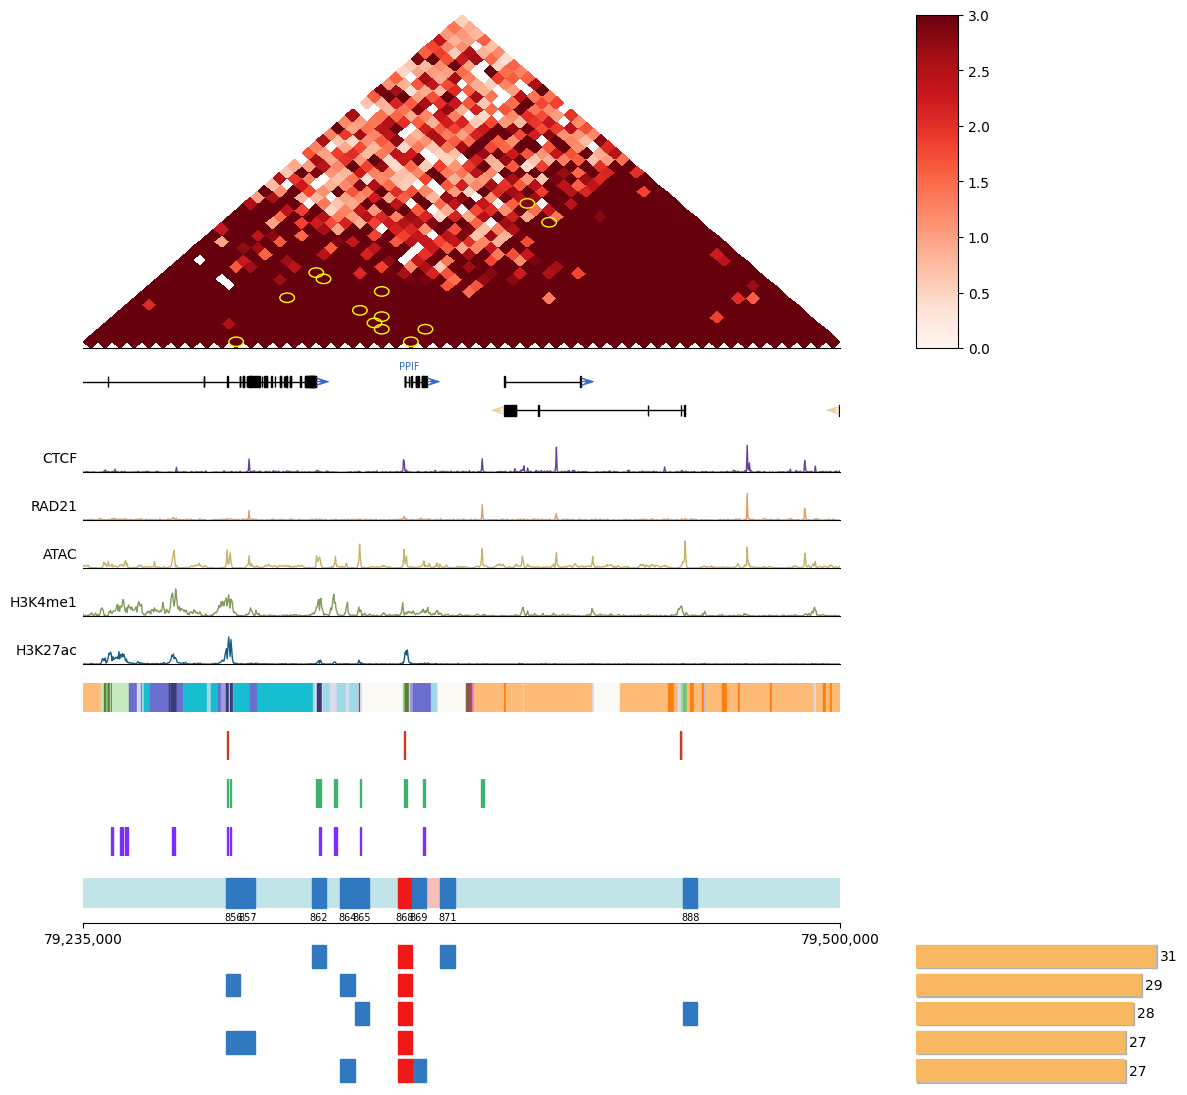

In [44]:
# 1. Set parameters
gene_name = 'PPIF'
cell_line = 'GM12878'

# 2. Step 1: Get gene region information and candidate test points
region_info = get_gene_region_info(gene_name=gene_name, cell_line=cell_line)
print("test_points:", region_info["test_points"])

# 3. Select target point (e.g., choose one from test_points or specify 535 directly)
point = 868

# 4. Step 2: Run Apriori analysis on the target point (support and confidence parameters are customizable)
apriori_res = run_apriori_analysis(
    gene_name=gene_name, 
    cell_line=cell_line, 
    point=point, 
    sub_anno=region_info["sub_anno"],
    support1=0.001, conf1=0.9,
    support2=0.0012, conf2=0.8,
    bin_padding=10, load_prerun=True
)

# 5. Define custom genomic feature coordinates
pos_regions = [
    (79285232, 79285732),
    (79286318, 79286818),
    (79316579, 79317079),
    (79317427, 79318156),
    (79322747, 79323659),
    (79331716, 79332216),
    (79347136, 79347713),
    (79347950, 79348450),
    (79354083, 79354583),
    (79374374, 79375158),
]
ABC_positions = [
    (79331716, 79332216),
    (79317427, 79318156),
    (79244524, 79245356),
    (79322747, 79323659),
    (79247734, 79248872),
    (79266031, 79267124),
    (79354083, 79354583),
    (79285232, 79285732),
    (79286318, 79286818),
    (79249428, 79250784),
]

# 6. Step 3: Call the visualization function
plot_apriori(
    gene_name=gene_name,
    cell_line=cell_line,
    point=point,
    region_info=region_info,
    apriori_res=apriori_res,
    pos_regions=pos_regions,
    ABC_positions=ABC_positions,
    custom_start=79235000, custom_end=79500000
)

test_points: [534, 535, 536]


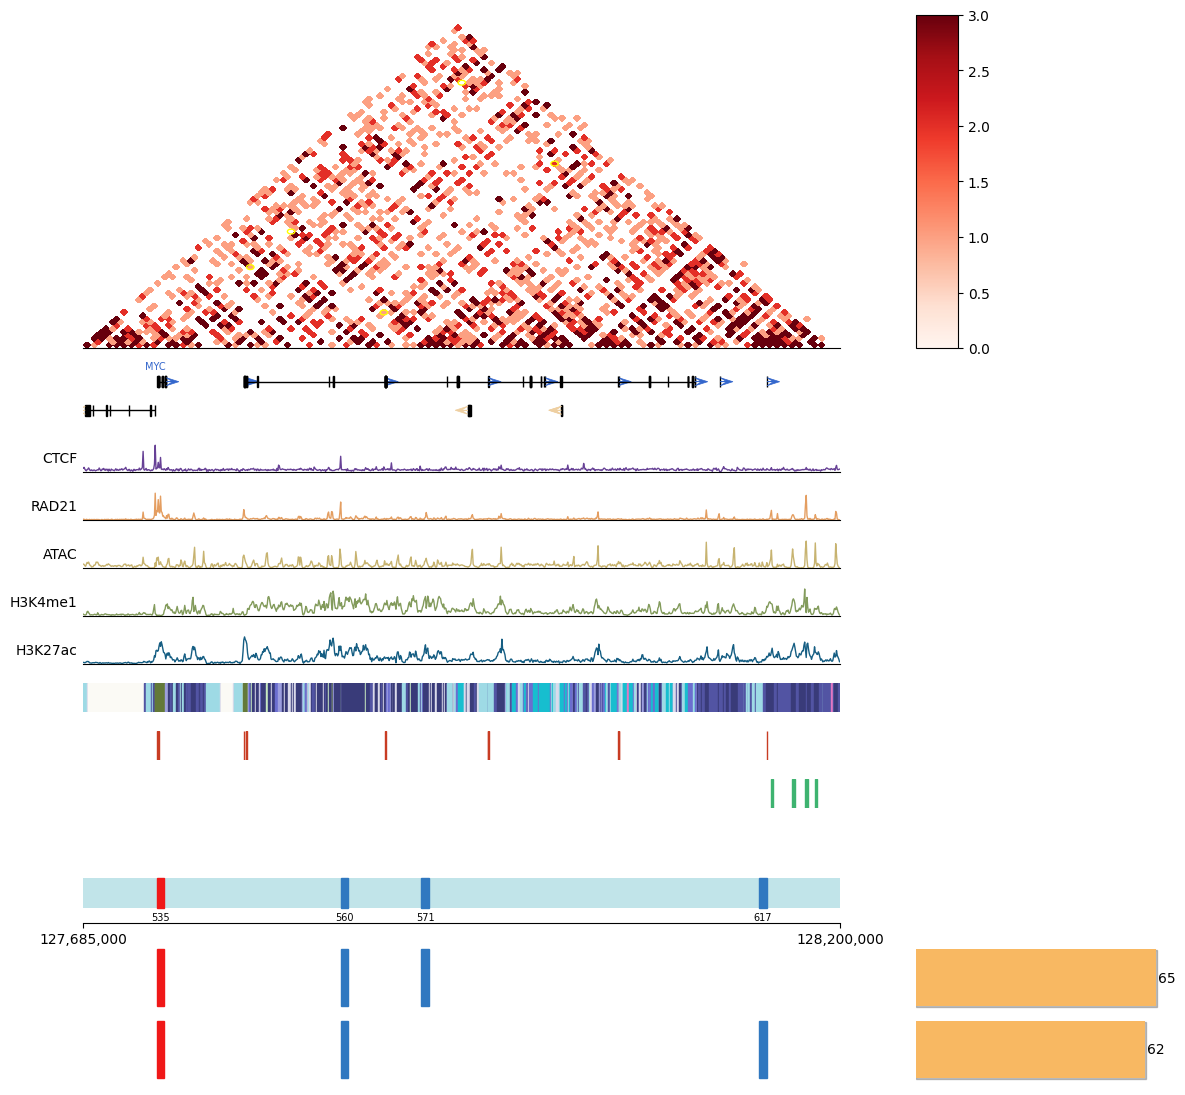

In [18]:
# 1. Set parameters
gene_name = 'MYC'
cell_line = 'A549'

# 2. Step 1: Get gene region information and candidate test points
region_info = get_gene_region_info(gene_name=gene_name, cell_line=cell_line)
print("test_points:", region_info["test_points"])

# 3. Select target point (e.g., choose one from test_points or specify 535 directly)
point = 535

# 4. Step 2: Run Apriori analysis on the target point (support and confidence parameters are customizable)
apriori_res = run_apriori_analysis(
    gene_name=gene_name, 
    cell_line=cell_line, 
    point=point, 
    sub_anno=region_info["sub_anno"],
    support1=0.001, conf1=0.9,
    support2=0.0035, conf2=0.95,
    bin_padding=10, load_prerun=True
)

# 5. Define custom genomic feature coordinates
pos_regions = [
    (128152848, 128153993), (128167183, 128169053),
    (128176171, 128177713), (128183039, 128183987)
]
ABC_positions = [
    (125545496, 125546611), (125546866, 125547570),
    (125664122, 125665123)
]

# 6. Step 3: Call the visualization function
plot_apriori(
    gene_name=gene_name,
    cell_line=cell_line,
    point=point,
    region_info=region_info,
    apriori_res=apriori_res,
    pos_regions=pos_regions,
    ABC_positions=ABC_positions
)

test_points: [984, 985, 986]


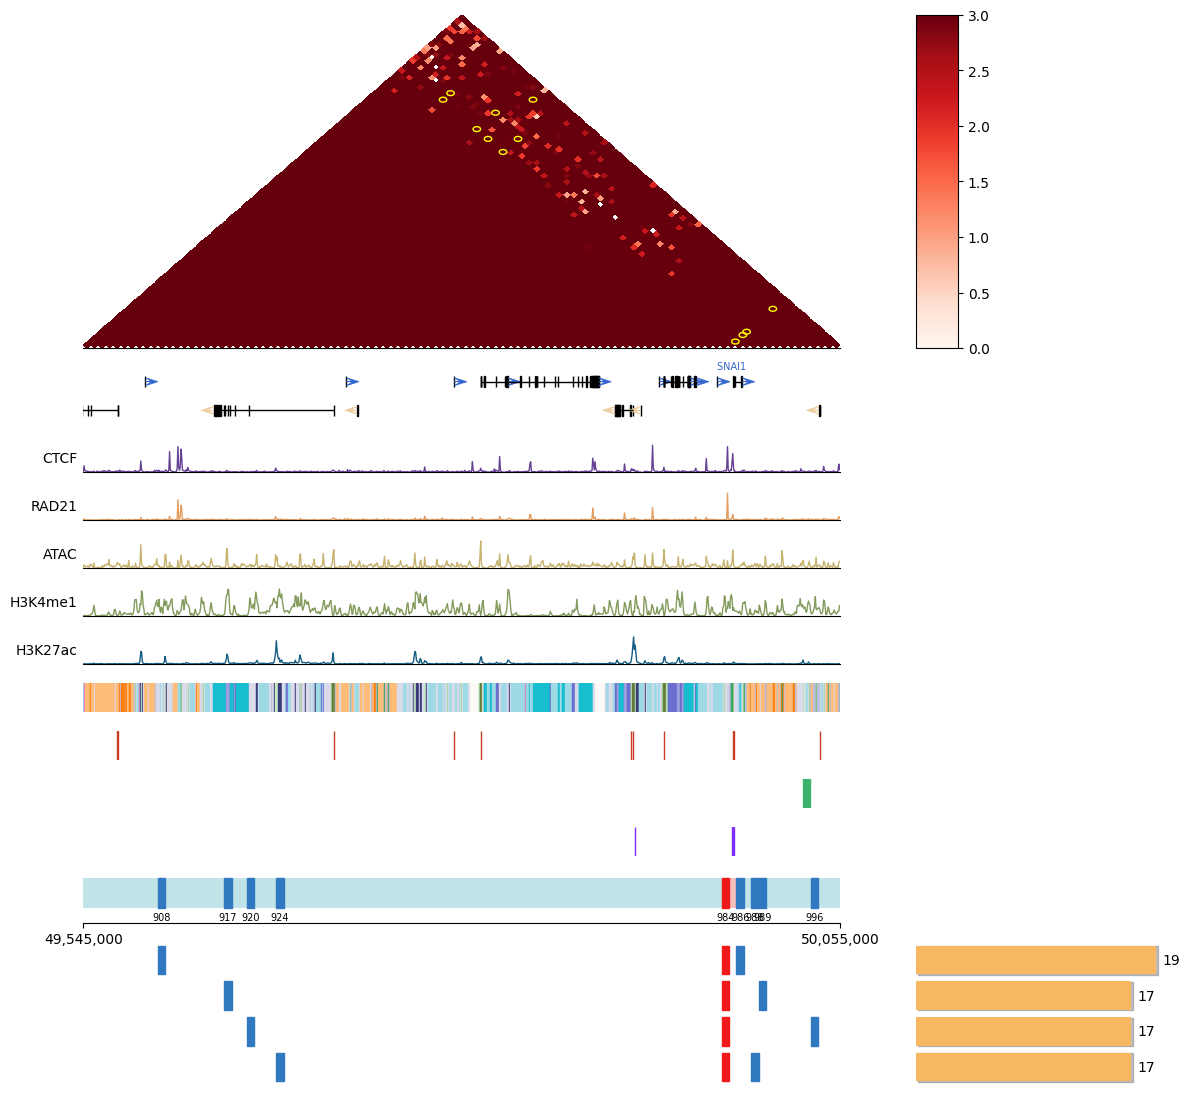

In [47]:
# 1. Set parameters
gene_name = 'SNAI1'
cell_line = 'HepG2'

# 2. Step 1: Get gene region information and candidate test points
region_info = get_gene_region_info(gene_name=gene_name, cell_line=cell_line)
print("test_points:", region_info["test_points"])

# 3. Select target point (e.g., choose one from test_points or specify 535 directly)
point = 984

# 4. Step 2: Run Apriori analysis on the target point (support and confidence parameters are customizable)
apriori_res = run_apriori_analysis(
    gene_name=gene_name, 
    cell_line=cell_line, 
    point=point, 
    sub_anno=region_info["sub_anno"],
    support1=0.001, conf1=0.9,
    support2=0.0005, conf2=0.85,
    bin_padding=10, load_prerun=True
)

# 5. Define custom genomic feature coordinates
pos_regions = [(50030215,50030215+4112)]

ABC_positions = [
    (49916361,49916861),
    (49982277,49983225),
    (50165594,50166460)
]


# 6. Step 3: Call the visualization function
plot_apriori(
    gene_name=gene_name,
    cell_line=cell_line,
    point=point,
    region_info=region_info,
    apriori_res=apriori_res,
    pos_regions=pos_regions,
    ABC_positions=ABC_positions
)

test_points: [220, 221, 222, 223, 224]


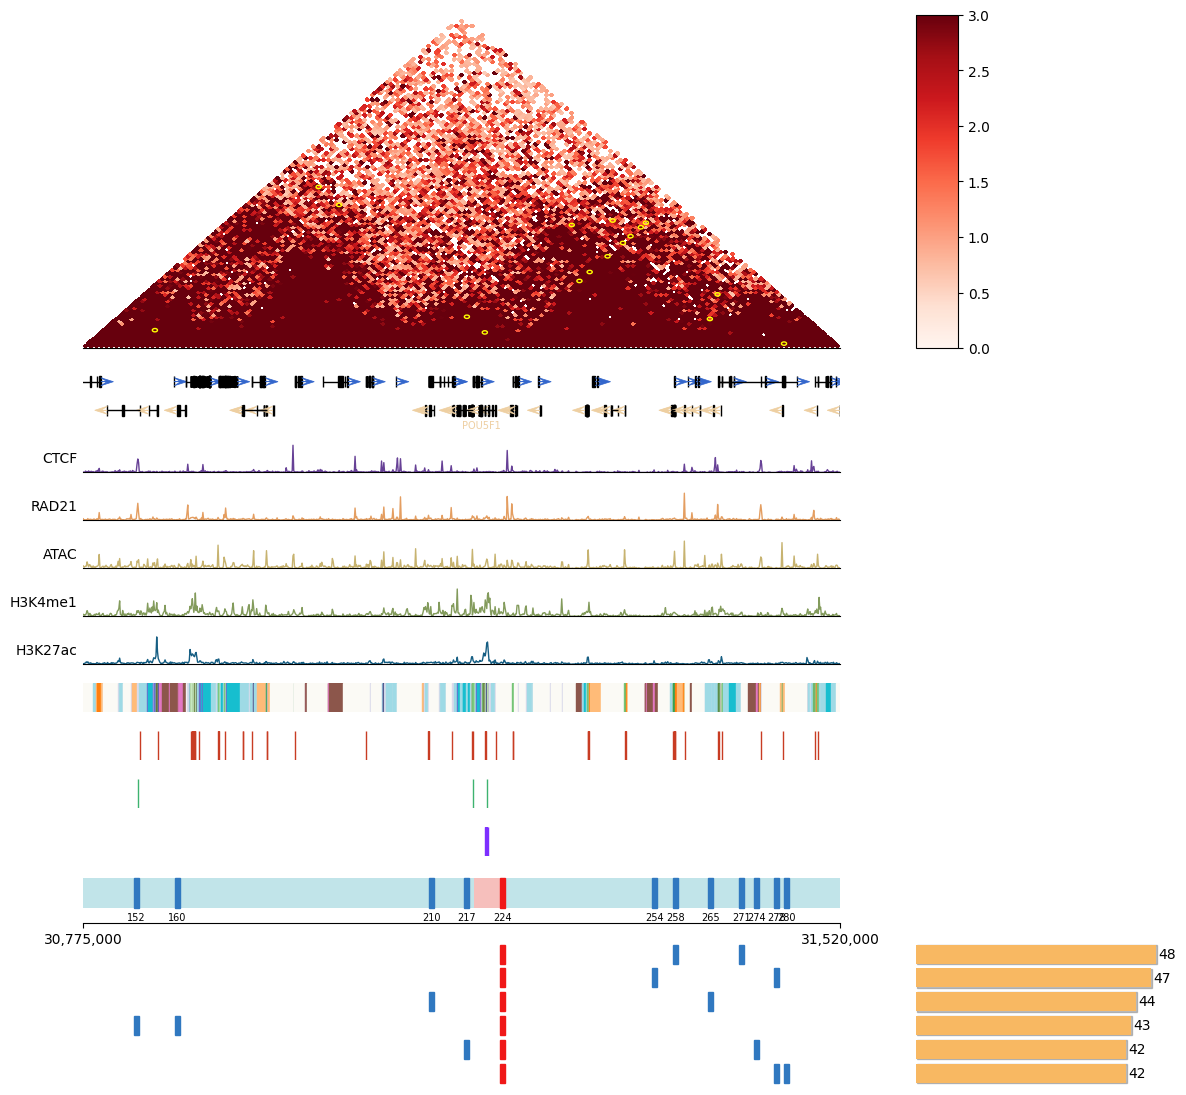

In [49]:
# 1. Set parameters
gene_name = 'POU5F1'
cell_line = 'H1'

# 2. Step 1: Get gene region information and candidate test points
region_info = get_gene_region_info(gene_name=gene_name, cell_line=cell_line)
print("test_points:", region_info["test_points"])

# 3. Select target point (e.g., choose one from test_points or specify 535 directly)
point = 224

# 4. Step 2: Run Apriori analysis on the target point (support and confidence parameters are customizable)
apriori_res = run_apriori_analysis(
    gene_name=gene_name, 
    cell_line=cell_line, 
    point=point, 
    sub_anno=region_info["sub_anno"],
    support1=0.0008, conf1=0.9,
    support2=0.00021, conf2=0.75,
    bin_padding=10, load_prerun=True
)

# 5. Define custom genomic feature coordinates
pos_regions =  [(31171821, 31172144), (30679065, 30679440), (30828585, 30829032), (31158759, 31158908)]


ABC_positions = [
    (31170455, 31170955),
    (31171807, 31172307),
    (31172873, 31173373),

]

# 6. Step 3: Call the visualization function
plot_apriori(
    gene_name=gene_name,
    cell_line=cell_line,
    point=point,
    region_info=region_info,
    apriori_res=apriori_res,
    pos_regions=pos_regions,
    ABC_positions=ABC_positions
)